In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/Users/shreyaparthiban/clean_uci_diabetes.csv")


In [30]:
df

,encounter_id,patient_nbr,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,number_diagnoses,change,diabetesMed,readmitted,readmitted_<30,admission_type_desc,discharge_disposition_desc,diag_1_cat,diag_2_cat,diag_3_cat
0,2278392,8222157,Caucasian,Female,[0-10),1,41,0,1,0,...,1,No,No,NO,0,NaN,Not Mapped,Endocrine,Other,Other
1,149190,55629189,Caucasian,Female,[10-20),3,59,0,18,0,...,9,Ch,Yes,>30,0,Emergency,Discharged to home,Endocrine,Endocrine,Endocrine
2,64410,86047875,AfricanAmerican,Female,[20-30),2,11,5,13,2,...,6,No,Yes,NO,0,Emergency,Discharged to home,Pregnancy,Endocrine,Supplementary
3,500364,82442376,Caucasian,Male,[30-40),2,44,1,16,0,...,7,Ch,Yes,NO,0,Emergency,Discharged to home,Infectious,Endocrine,Circulatory
4,16680,42519267,Caucasian,Male,[40-50),1,51,0,8,0,...,5,Ch,Yes,NO,0,Emergency,Discharged to home,Neoplasms,Neoplasms,Endocrine
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),3,51,0,16,0,...,9,Ch,Yes,>30,0,Emergency,Discharged/transferred to SNF,Endocrine,Mental,Circulatory
101762,443847782,74694222,AfricanAmerican,Female,[80-90),5,33,3,18,0,...,9,No,Yes,NO,0,Emergency,Discharged/transferred to ICF,Digestive,Endocrine,Symptoms
101763,443854148,41088789,Caucasian,Male,[70-80),1,53,0,9,1,...,13,Ch,Yes,NO,0,Emergency,Discharged to home,Infectious,Genitourinary,Mental
101764,443857166,31693671,Caucasian,Female,[80-90),10,45,2,21,0,...,9,Ch,Yes,NO,0,Urgent,Discharged/transferred to SNF,Injury,Blood,Injury


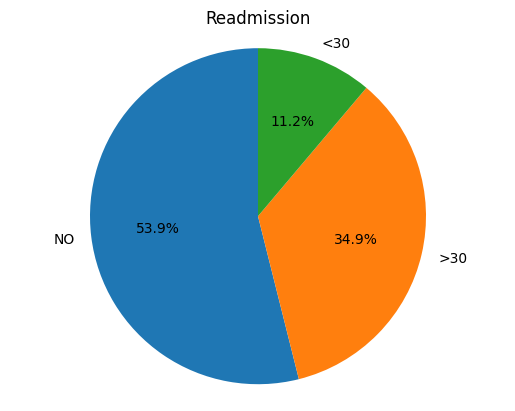

In [31]:
#plot target
counts = df['readmitted'].value_counts()

plt.pie(
    counts,
    labels=counts.index, 
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Readmission")
plt.axis('equal')
plt.show()

In [32]:
df['readmitted_<30']=df['readmitted'].apply(lambda x: 1 if x=='<30' else 0)
df.drop(columns="readmitted",inplace=True)
df['readmitted_<30'].value_counts()

readmitted_<30
0    90409
1    11357
Name: count, dtype: int64

In [37]:
def plot_cat_by_readmit(df, col, top_n=10):
    
    counts = df.groupby(['readmitted_<30', col]).size().unstack(fill_value=0)
    pct = counts.div(counts.sum(axis=1), axis=0).T

    if 1 in pct.columns:
        pct = pct.sort_values(by=1, ascending=False).head(top_n)
    else:
        pct = pct.head(top_n)

    pct = pct * 100 

    plt.figure(figsize=(2,4))

    ax = pct.plot(kind='barh')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

    ax.set_title(f'{col}: Readmitted vs Not', fontsize=10)
    ax.set_xlabel('Percent')
    ax.set_ylabel('')
    ax.legend(title='Readmitted', labels=['No','Yes'])
    plt.tight_layout()
    plt.savefig(f'{col}my_chart.png')

    plt.show()

/var/folders/kj/xf1gwqjj3xs_xwlpb70458h40000gn/T/ipykernel_78552/4227364479.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols=df.select_dtypes(include=['object']).columns.tolist()


<Figure size 200x400 with 0 Axes>

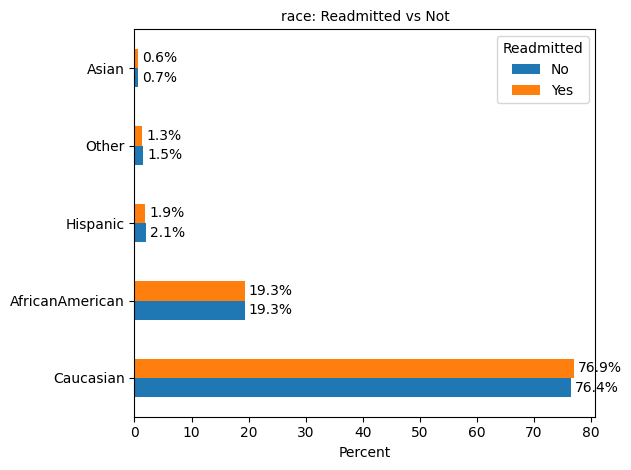

<Figure size 200x400 with 0 Axes>

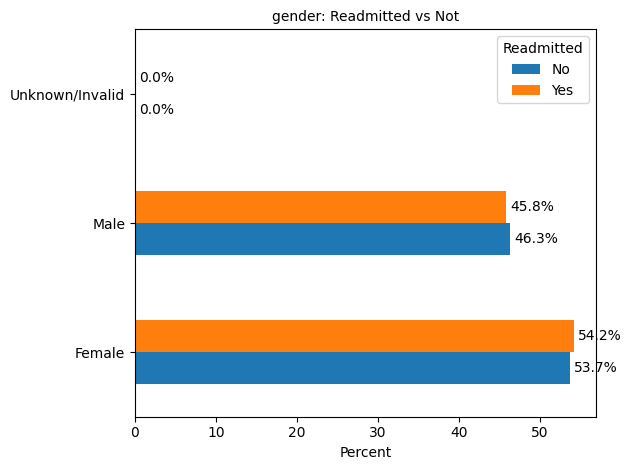

<Figure size 200x400 with 0 Axes>

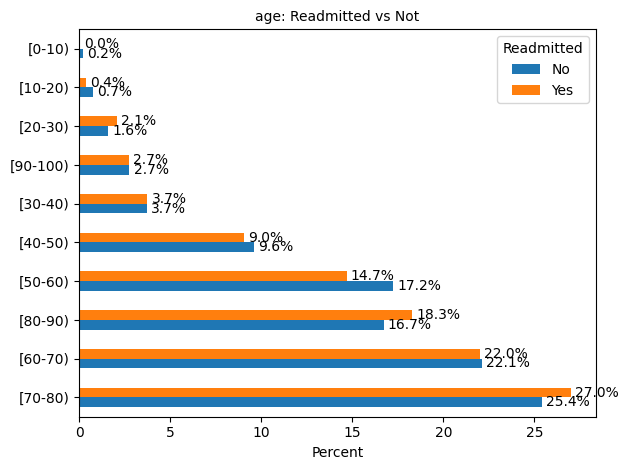

<Figure size 200x400 with 0 Axes>

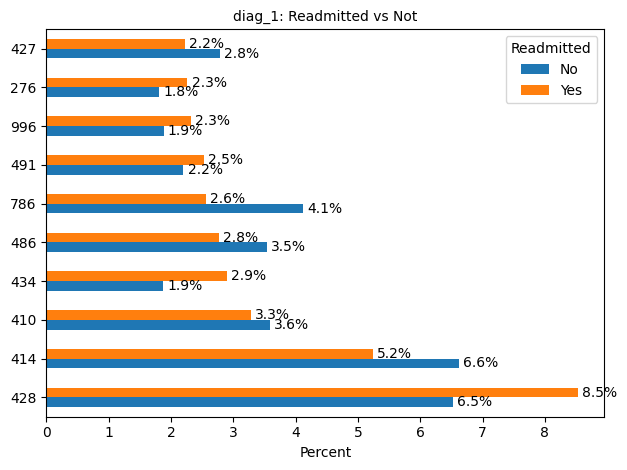

<Figure size 200x400 with 0 Axes>

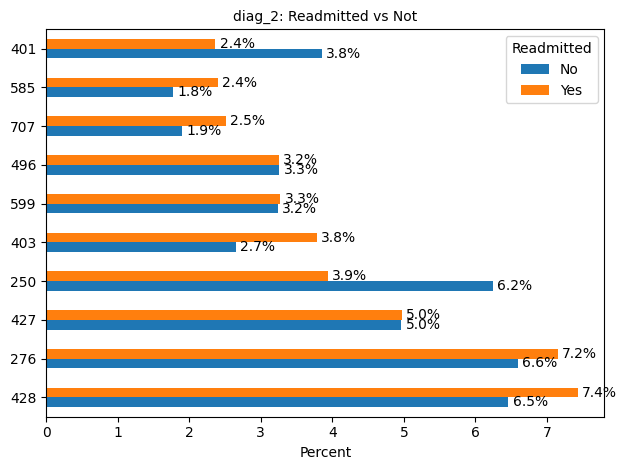

<Figure size 200x400 with 0 Axes>

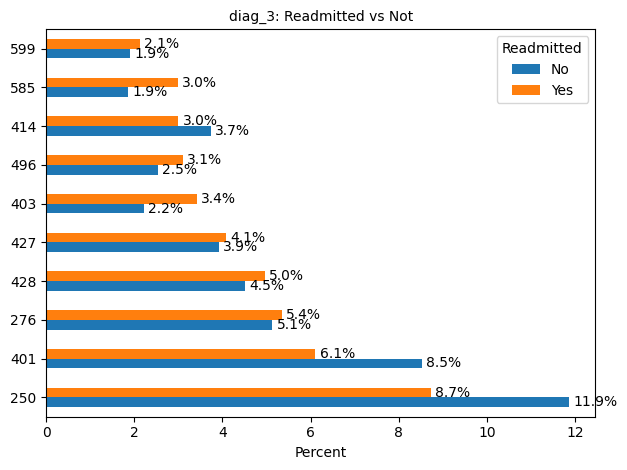

<Figure size 200x400 with 0 Axes>

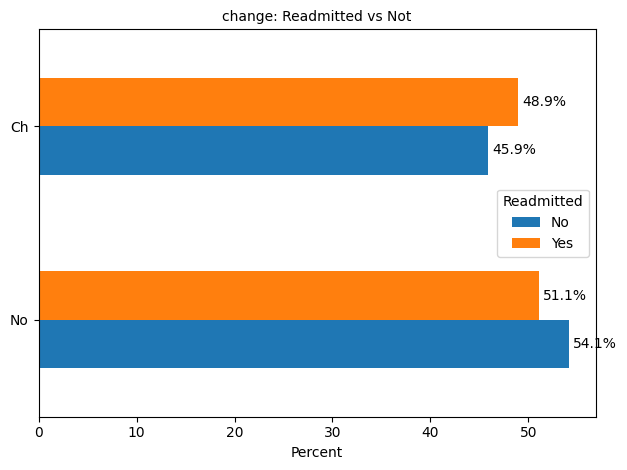

<Figure size 200x400 with 0 Axes>

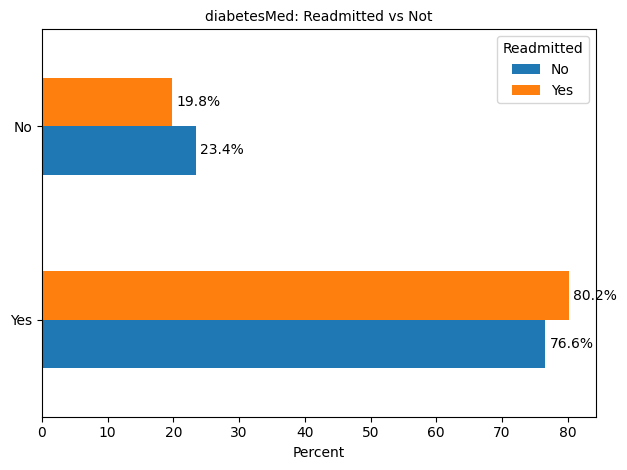

<Figure size 200x400 with 0 Axes>

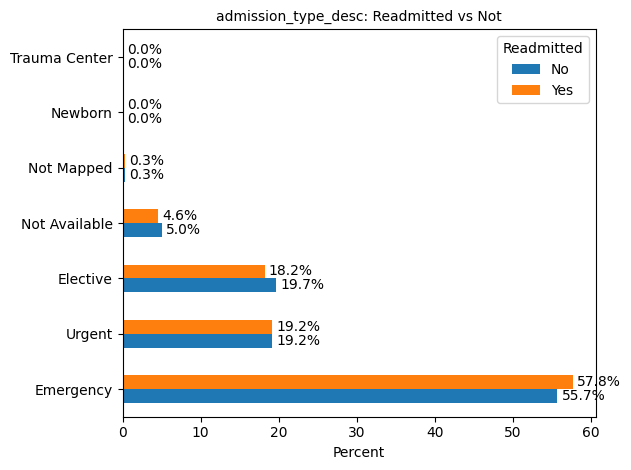

/var/folders/kj/xf1gwqjj3xs_xwlpb70458h40000gn/T/ipykernel_78552/235077979.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 200x400 with 0 Axes>

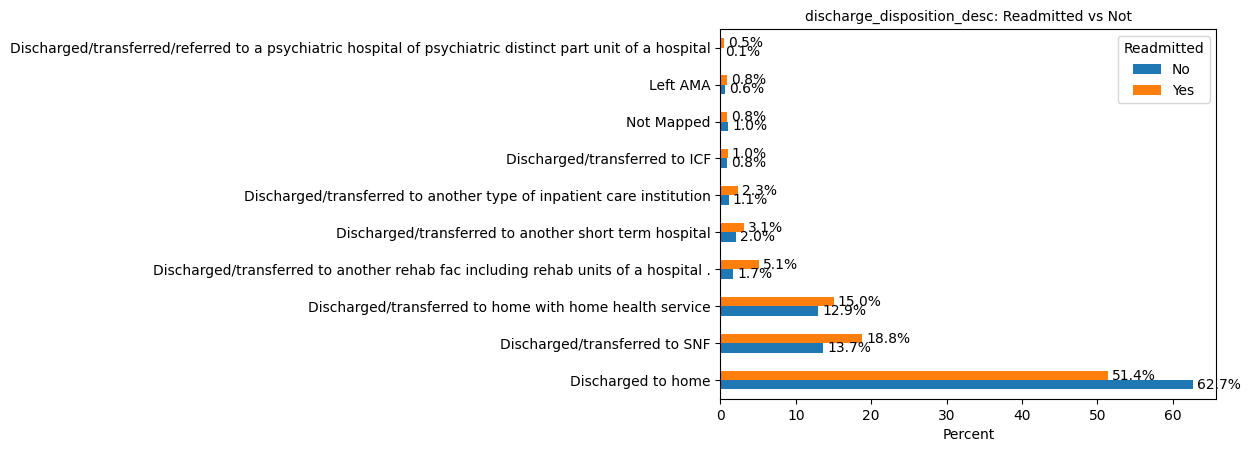

<Figure size 200x400 with 0 Axes>

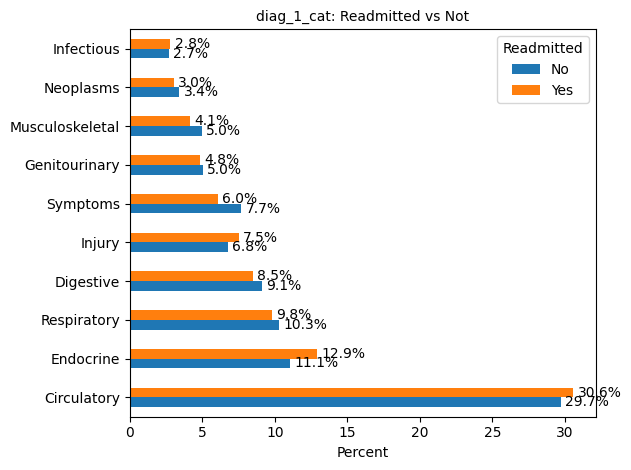

<Figure size 200x400 with 0 Axes>

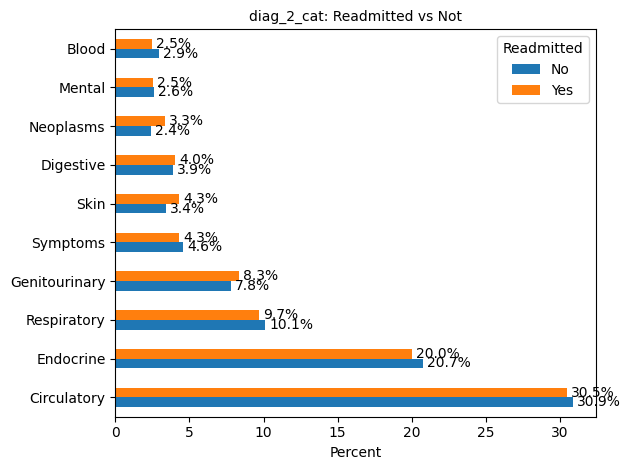

<Figure size 200x400 with 0 Axes>

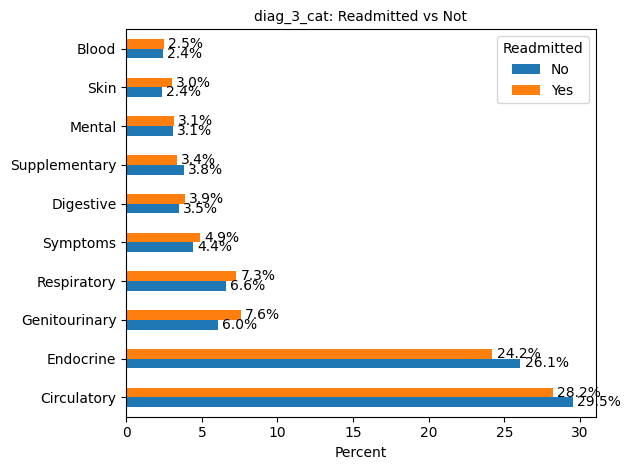

In [38]:
categorical_cols=df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    plot_cat_by_readmit(df,col)

In [19]:
def has_prefix(code, prefixes):
    return any(str(code).startswith(p) for p in prefixes)

def has_code_range(code, start, end):
    try:
        val = int(str(code))
        return start <= val <= end
    except:
        return False
def calculate_cci_dhoore(row):
    codes = [row['diag_1'], row['diag_2'], row['diag_3']]
    codes = [str(c) for c in codes if pd.notnull(c)]

    conditions = {
        'aids': False,
        'cerebro': False,
        'connective': False,
        'dementia': False,
        'liver': False,
        'metastatic': False,
        'malignancy': False,
        'pulmonary': False,
        'renal': False,
        'ulcer': False,
        'diabetes': False,
        'mi': False
    }

    for c in codes:

        if c.startswith('042'):
            conditions['aids'] = True

        elif has_prefix(c, ['430','431','432','433','435']):
            conditions['cerebro'] = True

        elif has_prefix(c, ['710','714','725']):
            conditions['connective'] = True

        elif has_prefix(c, ['290','291','294']):
            conditions['dementia'] = True

        elif has_prefix(c, ['070','570','572']):
            conditions['liver'] = True

        elif has_prefix(c, ['196','197','198','199']):
            conditions['metastatic'] = True

        elif (has_code_range(c, 140,195) or has_prefix(c, ['200','201','202','203','204','205','206','207','208'])):
            conditions['malignancy'] = True

        elif has_prefix(c, ['491','492','493']):
            conditions['pulmonary'] = True

        elif has_prefix(c, ['403','404','580','581','582','583','584','585','586']):
            conditions['renal'] = True

        elif has_prefix(c, ['531','532','533','534']):
            conditions['ulcer'] = True

        elif c.startswith('250'):
            conditions['diabetes'] = True

        elif has_prefix(c, ['410','411','412']):
            conditions['mi'] = True

    score = (
        conditions['aids'] * 6 +
        conditions['cerebro'] * 1 +
        conditions['connective'] * 1 +
        conditions['dementia'] * 1 +
        conditions['liver'] * 3 +
        conditions['metastatic'] * 6 +
        conditions['malignancy'] * 2 +
        conditions['pulmonary'] * 1 +
        conditions['renal'] * 2 +
        conditions['ulcer'] * 1 +
        conditions['diabetes'] * 2 +
        conditions['mi'] * 1
    )

    return score

In [20]:
df['cci'] = df.apply(calculate_cci_dhoore, axis=1)

In [21]:
df['cci'].value_counts().sort_index()

cci
0     37387
1     12239
2     39251
3      6813
4      3937
5       246
6       629
7        40
8      1049
9        46
10      125
11        4
Name: count, dtype: int64

<Axes: xlabel='cci'>

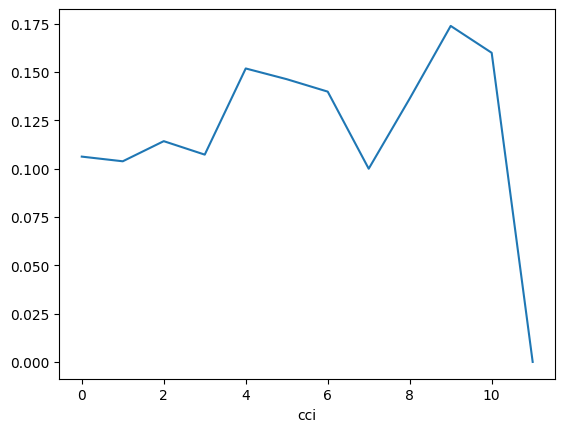

In [22]:
df.groupby('cci')['readmitted_<30'].mean().plot()

In [23]:
df.groupby('cci')['discharge_disposition_desc'].apply(
    lambda x: x.str.contains('Expired|Hospice', case=False, na=False).mean()
)

cci
0     0.022548
1     0.026636
2     0.018165
3     0.024218
4     0.025146
5     0.044715
6     0.135135
7     0.100000
8     0.147760
9     0.239130
10    0.072000
11    0.500000
Name: discharge_disposition_desc, dtype: float64

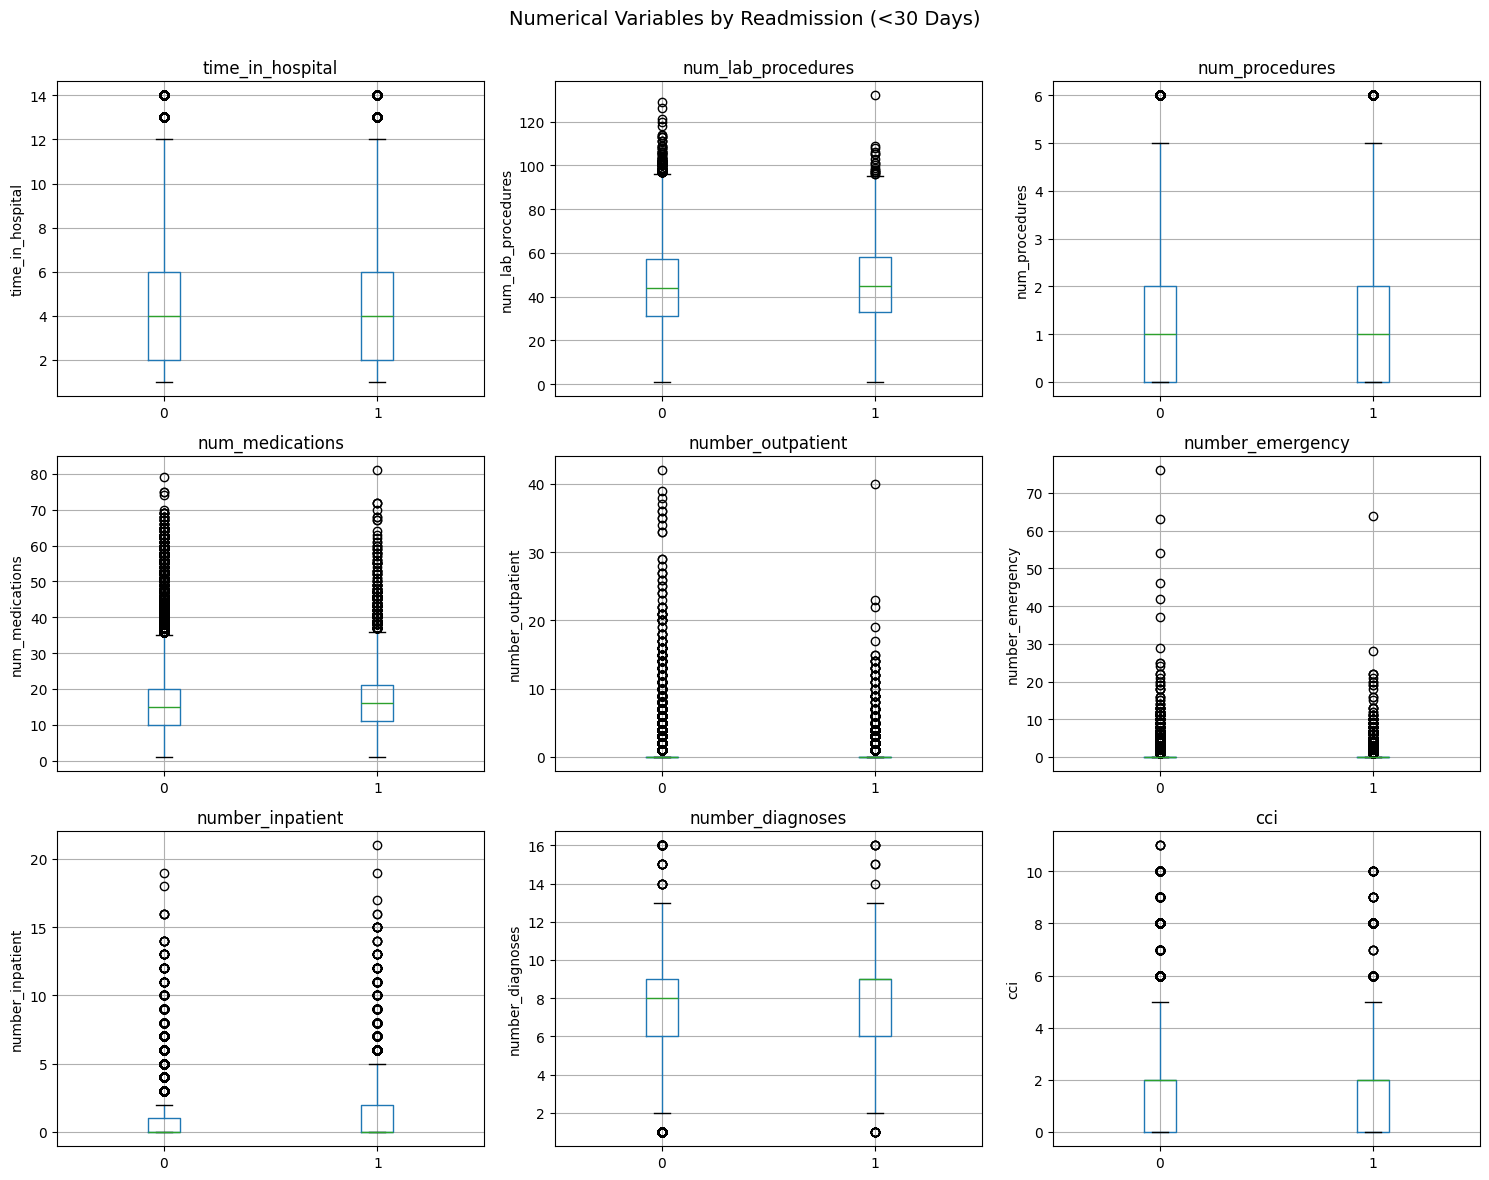

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'change', 'diabetesMed', 'readmitted_<30', 'admission_type_desc',
       'discharge_disposition_desc', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat',
       'cci'],
      dtype='str')
<class 'pandas.DataFrame'>


In [24]:
import math
# numeric columns (excluding target + IDs)
int_cols = df.select_dtypes(include=['int64']).columns.tolist()
exclude = ['readmitted_<30', 'encounter_id', 'patient_nbr']
int_cols = [col for col in int_cols if col not in exclude]

# grid size
n = len(int_cols)
cols = 3  # number of columns in grid
rows = math.ceil(n / cols)

# create figure
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

# plot each variable
for i, col in enumerate(int_cols):
    df.boxplot(column=col, by='readmitted_<30', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# clean formatting
plt.suptitle('Numerical Variables by Readmission (<30 Days)', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.92)

plt.show() 
print(df.columns)
print(type(df))

In [25]:
df = df.drop_duplicates(subset='patient_nbr', keep='first')
df = df.drop(columns=['encounter_id','patient_nbr'])

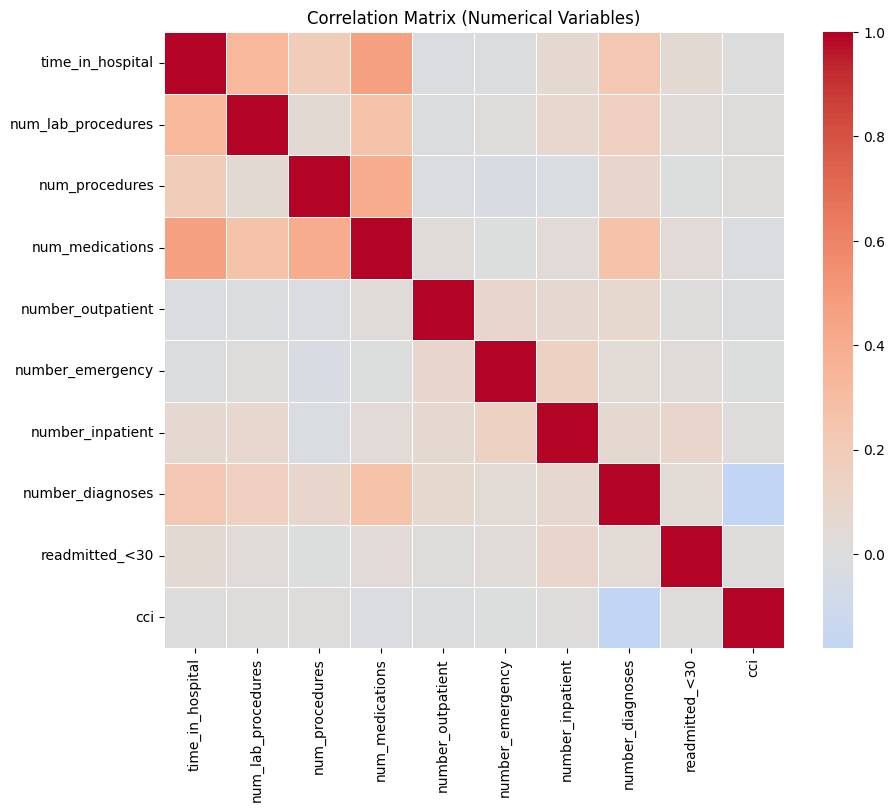

In [26]:
num_df = df.select_dtypes(include=['int64'])
corr = num_df.corr()

In [ ]:
# convert categoricals
df_encoded = pd.get_dummies(df, drop_first=True)

# correlation
corr = df_encoded.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [28]:
df.to_csv('dedup_uci_diabetes.csv')